# HARNet on the MHAR 5-min Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of a HARNet convolutional neural network on the $\mathcal{M}_{\mathrm{HAR}}$ 5-min feature set for the EURO STOXX 50 index.

This implementation follows the reference HARNet paper much more closely than the initial CNN prototype:

- the underlying realized-volatility source series is loaded from `MHAR_5min_intraday.csv`
- the effective HARNet receptive field is `20` trading days, corresponding to lags `[1, 5, 20]`
- the network uses the HARNet architecture with stacked dilated convolutional averaging layers
- the convolutional layers are initialized from the HAR averaging structure
- the output layer is initialized from an OLS HAR baseline fit
- the input series is scaled using a fixed MinMax transformation with bounds `[0, 0.001]`, matching the reference implementation
- the model is trained with the `QLIKE` loss and the Adam optimizer with learning rate `0.0001`
- mini-batches are formed from random subsequences with batch size `4`, label length `5`, and one batch per epoch
- `400` independent seed initializations are ranked by validation `QLIKE`
- forecasts are reported for:
  - the single best HARNet (`ensemble size = 1`)
  - the average of the top `5` HARNets (`ensemble size = 5`)

For comparability with the rest of the thesis, the final performance is still presented in terms of out-of-sample `MSE`, `RMSE`, `MAE`, and mean forecast error, and the end of the notebook retains the same forecast graph in annualized volatility units.


## 1. Loading Data
We load the full intraday-only MHAR series as the source time series for HARNet estimation, and we use `MALL_5min.csv` to recover the common final evaluation window used elsewhere in the thesis.


In [39]:
import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

mhar_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MHAR_5min_intraday.csv"
mall_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"

MHAR = pd.read_csv(mhar_path, index_col="Date", parse_dates=True)
MALL = pd.read_csv(mall_path, index_col="Date", parse_dates=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")
print(f"MHAR source shape: {MHAR.shape}")
print(f"MHAR source range: {MHAR.index[0].date()} to {MHAR.index[-1].date()}")
print(f"MALL comparison shape: {MALL.shape}")
print(f"MALL comparison range: {MALL.index[0].date()} to {MALL.index[-1].date()}")


Using device: cpu
MHAR source shape: (5674, 12)
MHAR source range: 1998-03-30 to 2020-08-07
MALL comparison shape: (5489, 31)
MALL comparison range: 1999-01-05 to 2020-08-06


## 2. Construct the HARNet Sample
The HARNet model is estimated on the raw univariate realized-variance series. To preserve comparability with the other MHAR models, we keep the final forecast-origin dates equal to the index of `MALL_5min.csv`, but we retain the earlier MHAR history in memory so the first train/validation/test observations still have the required 20-day lag history.

The HARNet predicts next-day realized variance, so the internal target positions correspond to the trading day after each forecast-origin date.


In [42]:
# Full source series used by HARNet
rv_source = MHAR[["RVD"]].copy()

# Forecast-origin dates are aligned to the common thesis comparison sample
origin_dates = MALL.index.copy()
origin_positions = MHAR.index.get_indexer(origin_dates)
assert (origin_positions >= 0).all(), "Some MALL dates were not found in the MHAR source index."
assert np.all(np.diff(origin_positions) == 1), "The aligned MHAR positions are expected to be contiguous."

# HARNet predicts next-day RV, so target positions are one step ahead of the forecast origins
max_source_pos = len(MHAR) - 1
target_positions = origin_positions + 1
assert target_positions[-1] <= max_source_pos, "The last next-day target is missing from the source series."

n = len(origin_dates)
print(f"Number of forecast origins: {n}")
print(f"First forecast-origin date: {origin_dates[0].date()}")
print(f"Last forecast-origin date:  {origin_dates[-1].date()}")
print(f"First target date:          {MHAR.index[target_positions[0]].date()}")
print(f"Last target date:           {MHAR.index[target_positions[-1]].date()}")


Number of forecast origins: 5489
First forecast-origin date: 1999-01-05
Last forecast-origin date:  2020-08-06
First target date:          1999-01-06
Last target date:           2020-08-07


## 3. Data Split
### 3.1 Train / Validation / Test Split (70 / 10 / 20)


As in the other neural-network notebooks, the HARNet evaluation uses a fixed chronological split into training, validation, and test samples.


In [46]:
# Train / Validation / Test split (70 / 10 / 20)
n_train = int(np.floor(0.70 * n))
n_val = int(np.floor(0.10 * n))
n_test = n - n_train - n_val

train_idx = origin_dates[:n_train]
val_idx = origin_dates[n_train:n_train + n_val]
test_idx = origin_dates[n_train + n_val:]

idx_range_train = [int(target_positions[0]), int(target_positions[0] + n_train)]
idx_range_val = [int(target_positions[n_train]), int(target_positions[n_train] + n_val)]
idx_range_test = [int(target_positions[n_train + n_val]), int(target_positions[n_train + n_val] + n_test)]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")
print(f"\nTarget index ranges in source series:")
print(f"Train:      {idx_range_train}")
print(f"Validation: {idx_range_val}")
print(f"Test:       {idx_range_test}")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)

Target index ranges in source series:
Train:      [185, 4027]
Validation: [4027, 4575]
Test:       [4575, 5674]


## 4. Scaling and Helper Structures
The reference HARNet implementation uses a fixed MinMax scaler with bounds `[0, 0.001]`. We mirror that setup here and work with the normalized univariate realized-volatility series in model estimation, while always converting forecasts back to the original scale for the final thesis comparison.


In [49]:
class MinMaxScalerFixed:
    def __init__(self, min_value=0.0, max_value=0.001):
        self.min = float(min_value)
        self.max = float(max_value)

    def transform(self, ts):
        return (ts - self.min) / (self.max - self.min)

    def fit_transform(self, ts):
        return self.transform(ts)

    def inverse_transform(self, ts):
        return ts * (self.max - self.min) + self.min


scaler = MinMaxScalerFixed(min_value=0.0, max_value=0.001)
ts_raw = rv_source[["RVD"]].to_numpy()
ts_norm = scaler.fit_transform(ts_raw)

MAX_LAG = 20
LAGS = [1, 5, 20]
LABEL_LENGTH = 5
BATCH_SIZE = 4
STEPS_PER_EPOCH = 1
MAX_EPOCHS = 10000
LEARNING_RATE = 0.0001
N_SEEDS = 400
TOP_K = 5

train_min_raw = np.min(ts_raw[idx_range_train[0]:idx_range_train[1], 0])
clip_value_norm = float(scaler.transform(np.array([[0.5 * train_min_raw]]))[0, 0])

print(f"Normalized series shape: {ts_norm.shape}")
print(f"Clip value in normalized space: {clip_value_norm:.6e}")
print(f"Min raw RV in training sample:   {train_min_raw:.6e}")


Normalized series shape: (5674, 1)
Clip value in normalized space: 1.955164e-05
Min raw RV in training sample:   3.910328e-08


## 5. HAR Baseline Fit for Initialization
In the reference implementation, HARNet is initialized from a linear HAR baseline. Here we estimate the OLS HAR model on the normalized series over the training sample and use those coefficients to initialize the HARNet output layer.


In [52]:
def get_avg_ts(ts, n_avg):
    ts_ret = np.empty(len(ts))
    ts_ret[:] = np.nan
    for k in range(n_avg - 1, len(ts)):
        ts_ret[k] = np.sum(ts[k - n_avg + 1:k + 1]) / n_avg
    return ts_ret


class HARBaseline:
    def __init__(self, lags, fit_method='OLS'):
        self.lags = lags
        self.fit_method = fit_method
        self.max_lag = int(np.max(lags))
        self.coeffs_ = None

    def get_X(self, ts_1d):
        X = np.zeros((len(ts_1d) - self.max_lag + 1, len(self.lags) + 1))
        ts_avgs = np.array([get_avg_ts(ts_1d, lag) for lag in self.lags])
        for k in range(len(X)):
            X[k, 0] = 1.0
            X[k, 1:] = ts_avgs[:, k + self.max_lag - 1]
        return X

    def fit(self, ts_2d):
        y = ts_2d[self.max_lag:, 0]
        X = self.get_X(ts_2d[:-1, 0])

        beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
        if self.fit_method == 'WLS':
            y_hat = X @ beta_ols
            weights = 1.0 / np.maximum(y_hat, 1e-8)
            W_sqrt = np.sqrt(weights)
            X_w = X * W_sqrt[:, None]
            y_w = y * W_sqrt
            self.coeffs_ = np.linalg.lstsq(X_w, y_w, rcond=None)[0]
        else:
            self.coeffs_ = beta_ols

    @property
    def coeffs(self):
        return self.coeffs_


har_baseline = HARBaseline(LAGS, fit_method='OLS')
har_fit_slice = ts_norm[idx_range_train[0] - MAX_LAG:idx_range_train[1], :]
har_baseline.fit(har_fit_slice)
har_coeffs = har_baseline.coeffs.astype(np.float32)

print("HAR OLS coefficients used for HARNet initialization:")
print(f"  Constant: {har_coeffs[0]:.6f}")
print(f"  Lag 1:    {har_coeffs[1]:.6f}")
print(f"  Lag 5:    {har_coeffs[2]:.6f}")
print(f"  Lag 20:   {har_coeffs[3]:.6f}")


HAR OLS coefficients used for HARNet initialization:
  Constant: 0.020780
  Lag 1:    0.253226
  Lag 5:    0.406148
  Lag 20:   0.211173


## 6. HARNet Architecture
The HARNet architecture follows the public reference implementation:

- lags `[1, 5, 20]`
- one filter in each dilated convolutional averaging layer
- no convolutional bias terms
- ReLU activation in the dilated convolutional blocks
- output layer initialized from the OLS HAR baseline coefficients
- clipping of predictions at a small positive floor in normalized space

The first convolution learns the 5-day aggregation and the second dilated convolution learns the 20-day aggregation from the 5-day block.


In [55]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, bias=False):
        super().__init__()
        self.pad = dilation * (kernel_size - 1)
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            bias=bias
        )

    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.pad, 0))
        return self.conv(x)


class HARNet(nn.Module):
    def __init__(self, lags, regr_coeff, clip_value, filters_dconv=1, use_bias_dconv=False, activation='relu'):
        super().__init__()
        self.lags = lags
        self.max_lag = int(np.max(lags))
        self.register_buffer('clip_value', torch.tensor(float(clip_value), dtype=torch.float32))

        if np.any(np.array(self.lags)[1:] % np.array(self.lags)[:-1]):
            raise ValueError('Each lag must be a multiple of the previous one.')

        self.avg_layers = nn.ModuleList()
        self.avg_layers.append(
            CausalConv1d(1, filters_dconv, kernel_size=self.lags[1], dilation=1, bias=use_bias_dconv)
        )
        for k in range(1, len(self.lags) - 1):
            self.avg_layers.append(
                CausalConv1d(
                    in_channels=1,
                    out_channels=filters_dconv,
                    kernel_size=int(self.lags[k + 1] / self.lags[k]),
                    dilation=self.lags[k],
                    bias=False
                )
            )

        self.output_layer = nn.Linear(len(self.lags) + 1, 1, bias=False)
        self.activation = nn.ReLU() if activation.lower() == 'relu' else nn.Identity()
        self._initialize_weights(regr_coeff)

    def _initialize_weights(self, regr_coeff):
        with torch.no_grad():
            self.avg_layers[0].conv.weight.fill_(1.0 / self.lags[1])
            for k in range(1, len(self.lags) - 1):
                self.avg_layers[k].conv.weight.fill_(self.lags[k] / self.lags[k + 1])
            self.output_layer.weight.copy_(torch.tensor(regr_coeff[None, :], dtype=torch.float32))

    def forward(self, inputs):
        # inputs shape: (batch, time, channels)
        inputs_ch = inputs.transpose(1, 2)  # (batch, channels, time)
        avgs = torch.cat([torch.ones_like(inputs), inputs], dim=-1)
        curr = inputs_ch

        for avg_layer in self.avg_layers:
            avg_out = avg_layer(curr).transpose(1, 2)
            avg_out = self.activation(avg_out)
            avgs = torch.cat([avgs, avg_out], dim=-1)
            curr = avg_out.transpose(1, 2)

        out = self.output_layer(avgs)
        out = out[:, self.max_lag - 1:, :]
        out = torch.clamp(out, min=self.clip_value, max=1000.0)
        return out.squeeze(-1)


model_test = HARNet(LAGS, regr_coeff=har_coeffs, clip_value=clip_value_norm).to(device)
print(model_test)
print(f"\nReceptive field:      {MAX_LAG}")
print(f"Dilated lag blocks:   {LAGS}")
print(f"Conv filters / layer: 1")
print(f"Output coefficients:  {len(har_coeffs)}")
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters())}")


HARNet(
  (avg_layers): ModuleList(
    (0): CausalConv1d(
      (conv): Conv1d(1, 1, kernel_size=(5,), stride=(1,), bias=False)
    )
    (1): CausalConv1d(
      (conv): Conv1d(1, 1, kernel_size=(4,), stride=(1,), dilation=(5,), bias=False)
    )
  )
  (output_layer): Linear(in_features=4, out_features=1, bias=False)
  (activation): ReLU()
)

Receptive field:      20
Dilated lag blocks:   [1, 5, 20]
Conv filters / layer: 1
Output coefficients:  4

Total parameters: 13


## 7. HARNet Loss and Training Utilities
The reference implementation optimizes the `QLIKE` loss. We therefore train the HARNet on normalized realized-variance targets with QLIKE, using the same seed-ranking logic as in the other neural-network notebooks.


In [58]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)


def qlike_loss(y_true, y_pred):
    y_true = torch.clamp(y_true, min=1e-12)
    y_pred = torch.clamp(y_pred, min=1e-12)
    ratio = y_true / y_pred
    return torch.mean(ratio - torch.log(ratio) - 1.0)


def make_batch(ts_norm_array, valid_start_positions, batch_size, label_length, max_lag):
    x_batch = []
    y_batch = []
    for _ in range(batch_size):
        idx = int(np.random.choice(valid_start_positions))
        x_batch.append(ts_norm_array[idx - max_lag:idx + label_length - 1, :])
        y_batch.append(ts_norm_array[idx:idx + label_length, 0])
    x_batch = np.stack(x_batch, axis=0)
    y_batch = np.stack(y_batch, axis=0)
    return x_batch, y_batch


def predict_norm_range(model, ts_norm_array, idx_range, max_lag):
    x = ts_norm_array[idx_range[0] - max_lag:idx_range[1] - 1, :][None, :, :]
    with torch.no_grad():
        pred = model(to_tensor(x)).detach().cpu().numpy().flatten()
    target = ts_norm_array[idx_range[0]:idx_range[1], 0]
    return pred, target


def inverse_transform_1d(values, scaler_obj):
    return scaler_obj.inverse_transform(values.reshape(-1, 1)).flatten()


def compute_metrics(model, ts_raw_array, ts_norm_array, idx_range, scaler_obj, max_lag):
    pred_norm, target_norm = predict_norm_range(model, ts_norm_array, idx_range, max_lag)
    pred_raw = inverse_transform_1d(pred_norm, scaler_obj)
    target_raw = ts_raw_array[idx_range[0]:idx_range[1], 0]

    qlike_norm = np.mean(target_norm / pred_norm - np.log(target_norm / pred_norm) - 1.0)
    qlike_raw = np.mean(target_raw / pred_raw - np.log(target_raw / pred_raw) - 1.0)
    mse_raw = np.mean((target_raw - pred_raw) ** 2)
    mae_raw = np.mean(np.abs(target_raw - pred_raw))

    return {
        "pred_norm": pred_norm,
        "target_norm": target_norm,
        "pred_raw": pred_raw,
        "target_raw": target_raw,
        "val_qlike_norm": qlike_norm,
        "val_qlike_raw": qlike_raw,
        "val_mse_raw": mse_raw,
        "val_mae_raw": mae_raw,
    }


## 8. Training Function
We train the HARNet using the same core defaults as the reference implementation:

- `Adam`
- learning rate `0.0001`
- `10000` maximum epochs
- one random mini-batch per epoch
- batch size `4`
- label length `5`
- validation ranking based on normalized `QLIKE`

The best parameter state for each seed is retained according to validation `QLIKE`.


In [61]:
def train_harnet(ts_raw_array, ts_norm_array, idx_range_train, idx_range_val,
                 regr_coeff, clip_value, lags,
                 learning_rate=LEARNING_RATE,
                 max_epochs=MAX_EPOCHS,
                 batch_size=BATCH_SIZE,
                 label_length=LABEL_LENGTH,
                 steps_per_epoch=STEPS_PER_EPOCH,
                 seed=0):

    set_seed(seed)
    model = HARNet(lags, regr_coeff=regr_coeff, clip_value=clip_value).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    valid_start_positions = np.arange(idx_range_train[0], idx_range_train[1] - label_length + 1)

    best_metric = np.inf
    best_state = None
    best_epoch = 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        for _ in range(steps_per_epoch):
            x_batch, y_batch = make_batch(ts_norm_array, valid_start_positions, batch_size, label_length, model.max_lag)
            x_batch_t = to_tensor(x_batch)
            y_batch_t = to_tensor(y_batch)

            optimizer.zero_grad()
            pred_batch = model(x_batch_t)
            loss = qlike_loss(y_batch_t, pred_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        metrics_val = compute_metrics(model, ts_raw_array, ts_norm_array, idx_range_val, scaler, model.max_lag)
        current_metric = metrics_val["val_qlike_norm"]
        history.append({
            "epoch": epoch + 1,
            "val_qlike_norm": metrics_val["val_qlike_norm"],
            "val_qlike_raw": metrics_val["val_qlike_raw"],
            "val_mse_raw": metrics_val["val_mse_raw"],
            "val_mae_raw": metrics_val["val_mae_raw"],
        })

        if current_metric < best_metric:
            best_metric = current_metric
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

    model.load_state_dict(best_state)
    model.eval()
    return model, best_metric, best_epoch, pd.DataFrame(history)


## 9. Initial Validation Check
Before estimating the full ensemble, we train one HARNet using a single seed as a sanity check.


In [64]:
model_check, val_metric_check, best_epoch_check, history_check = train_harnet(
    ts_raw_array=ts_raw,
    ts_norm_array=ts_norm,
    idx_range_train=idx_range_train,
    idx_range_val=idx_range_val,
    regr_coeff=har_coeffs,
    clip_value=clip_value_norm,
    lags=LAGS,
    seed=0
)

metrics_check = compute_metrics(model_check, ts_raw, ts_norm, idx_range_val, scaler, MAX_LAG)

print(f"Validation QLIKE (normalized, seed=0): {val_metric_check:.6e}")
print(f"Best epoch:                           {best_epoch_check}")
print(f"Validation QLIKE (raw scale):        {metrics_check['val_qlike_raw']:.6e}")
print(f"Validation MSE (raw scale):          {metrics_check['val_mse_raw']:.6e}")
print(f"Validation MAE (raw scale):          {metrics_check['val_mae_raw']:.6e}")


Validation QLIKE (normalized, seed=0): 2.091021e-01
Best epoch:                           55
Validation QLIKE (raw scale):        2.091021e-01
Validation MSE (raw scale):          9.894421e-09
Validation MAE (raw scale):          5.527689e-05


## 10. Ensemble Training on the Fixed Estimation Window
Following the thesis neural-network workflow, we train `400` independent HARNets with different seeds, rank them by validation `QLIKE`, and retain:

- the single best HARNet (`ensemble size = 1`)
- the top `5` HARNets (`ensemble size = 5`)


In [67]:
seed_records = []
start_time = time.time()

print(f"Training {N_SEEDS} independent HARNets...")
for seed in range(N_SEEDS):
    model_i, val_metric_i, best_epoch_i, _ = train_harnet(
        ts_raw_array=ts_raw,
        ts_norm_array=ts_norm,
        idx_range_train=idx_range_train,
        idx_range_val=idx_range_val,
        regr_coeff=har_coeffs,
        clip_value=clip_value_norm,
        lags=LAGS,
        seed=seed
    )

    metrics_val_i = compute_metrics(model_i, ts_raw, ts_norm, idx_range_val, scaler, MAX_LAG)
    seed_records.append({
        "seed": seed,
        "val_qlike_norm": metrics_val_i["val_qlike_norm"],
        "val_qlike_raw": metrics_val_i["val_qlike_raw"],
        "val_mse_raw": metrics_val_i["val_mse_raw"],
        "best_epoch": best_epoch_i,
        "model": model_i
    })

    if (seed + 1) % 25 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Completed {seed + 1:3d}/{N_SEEDS} seeds | Elapsed: {elapsed:.2f} min")

elapsed = (time.time() - start_time) / 60
print(f"\nTraining time: {elapsed:.2f} minutes")

seed_records.sort(key=lambda x: x["val_qlike_norm"])
best_network = seed_records[0]
top5_networks = seed_records[:TOP_K]

ranking_df = pd.DataFrame([
    {
        "rank": i + 1,
        "seed": rec["seed"],
        "val_qlike_norm": rec["val_qlike_norm"],
        "val_qlike_raw": rec["val_qlike_raw"],
        "val_mse_raw": rec["val_mse_raw"],
        "best_epoch": rec["best_epoch"]
    }
    for i, rec in enumerate(seed_records)
])

print("\nTop seeds by validation QLIKE:")
display(ranking_df.head(10))


Training 400 independent HARNets...
  Completed  25/400 seeds | Elapsed: 2.29 min
  Completed  50/400 seeds | Elapsed: 4.62 min
  Completed  75/400 seeds | Elapsed: 6.98 min
  Completed 100/400 seeds | Elapsed: 9.33 min
  Completed 125/400 seeds | Elapsed: 11.68 min
  Completed 150/400 seeds | Elapsed: 14.01 min
  Completed 175/400 seeds | Elapsed: 16.33 min
  Completed 200/400 seeds | Elapsed: 18.68 min
  Completed 225/400 seeds | Elapsed: 20.99 min
  Completed 250/400 seeds | Elapsed: 23.34 min
  Completed 275/400 seeds | Elapsed: 25.66 min
  Completed 300/400 seeds | Elapsed: 27.98 min
  Completed 325/400 seeds | Elapsed: 30.36 min
  Completed 350/400 seeds | Elapsed: 32.65 min
  Completed 375/400 seeds | Elapsed: 34.92 min
  Completed 400/400 seeds | Elapsed: 37.17 min

Training time: 37.17 minutes

Top seeds by validation QLIKE:


,rank,seed,val_qlike_norm,val_qlike_raw,val_mse_raw,best_epoch
0,1,383,0.208903,0.208903,9.968461e-09,921
1,2,279,0.208922,0.208922,9.938762e-09,617
2,3,219,0.208932,0.208932,9.982812e-09,1077
3,4,26,0.208934,0.208934,9.950605e-09,737
4,5,97,0.208943,0.208943,9.905339e-09,69
5,6,129,0.208947,0.208947,9.906634e-09,86
6,7,289,0.208959,0.208959,9.901887e-09,84
7,8,177,0.208961,0.208961,9.990522e-09,1078
8,9,167,0.208963,0.208963,9.903757e-09,91
9,10,325,0.208964,0.208964,9.955226e-09,741


## 11. One-Day-Ahead Test Forecasts
The retained HARNet models are evaluated over the fixed test sample. For thesis comparability, we report forecast performance in terms of raw-scale `MSE`, `RMSE`, `MAE`, and mean error, even though the model is trained using `QLIKE`.


In [70]:
def get_test_forecast_raw(model, ts_raw_array, ts_norm_array, idx_range, scaler_obj, max_lag):
    pred_norm, _ = predict_norm_range(model, ts_norm_array, idx_range, max_lag)
    pred_raw = inverse_transform_1d(pred_norm, scaler_obj)
    return pred_raw

pred_best = get_test_forecast_raw(best_network["model"], ts_raw, ts_norm, idx_range_test, scaler, MAX_LAG)
pred_top5_all = [
    get_test_forecast_raw(rec["model"], ts_raw, ts_norm, idx_range_test, scaler, MAX_LAG)
    for rec in top5_networks
]
pred_top5 = np.mean(pred_top5_all, axis=0)

y_test = ts_raw[idx_range_test[0]:idx_range_test[1], 0]

results_CNN = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast_best": pred_best,
    "RV_forecast_top5": pred_top5
}, index=test_idx)

errors_best = results_CNN["RV_actual"] - results_CNN["RV_forecast_best"]
errors_top5 = results_CNN["RV_actual"] - results_CNN["RV_forecast_top5"]

mse_best = np.mean(errors_best ** 2)
mse_top5 = np.mean(errors_top5 ** 2)

print(f"Forecast period: {test_idx[0].date()} to {test_idx[-1].date()}")
print(f"\nHARNet_best MSE: {mse_best:.6e}")
print(f"HARNet_top5 MSE: {mse_top5:.6e}")


Forecast period: 2016-04-21 to 2020-08-06

HARNet_best MSE: 5.553321e-08
HARNet_top5 MSE: 5.545662e-08


## 12. Save Forecasts and Summary Statistics


In [ ]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Neural Networks"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Neural Networks"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

results_CNN.to_csv(os.path.join(forecast_path, "forecasts_CNN.csv"))
mse_summary_CNN = pd.DataFrame({
    "Model": ["HARNet_best", "HARNet_top5"],
    "MSE": [mse_best, mse_top5],
    "RMSE": [np.sqrt(mse_best), np.sqrt(mse_top5)],
    "MAE": [errors_best.abs().mean(), errors_top5.abs().mean()],
    "Mean_Error": [errors_best.mean(), errors_top5.mean()]
}).set_index("Model")

mse_summary_CNN.to_csv(os.path.join(mse_path, "mse_summary_CNN.csv"))

print(f"Forecasts saved to:   {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_CNN)}")
print()
print(mse_summary_CNN.to_string())


## 13. Results
### 13.1 Forecast Visualization


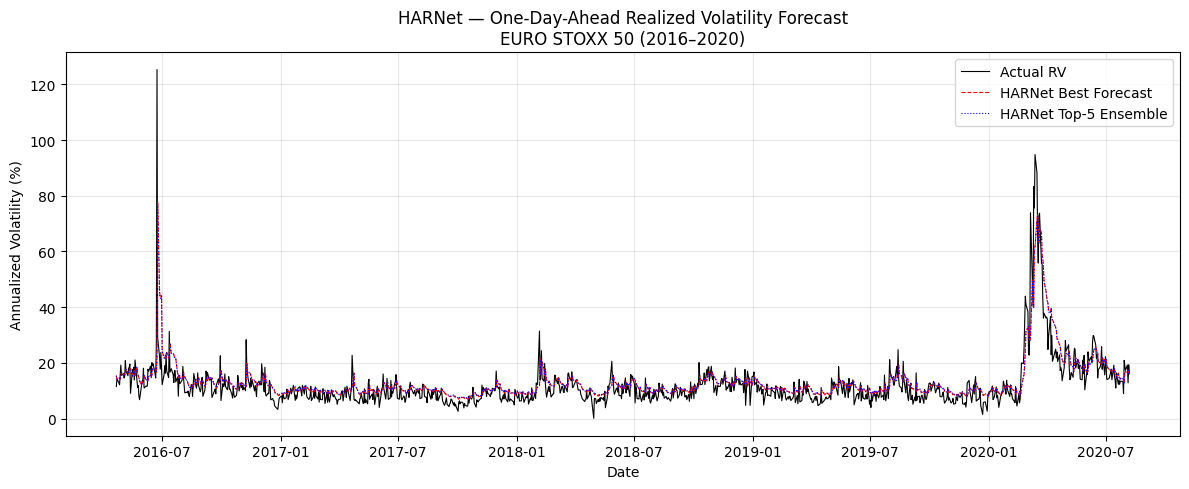


Summary of forecast errors:

HARNet Best:
  Mean error:  -3.870293e-06
  RMSE:        2.356548e-04
  MAE:         4.944348e-05

HARNet Top-5 Ensemble:
  Mean error:  -3.870123e-06
  RMSE:        2.354923e-04
  MAE:         4.949907e-05


In [72]:
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_CNN["RV_actual"] * 252) * 100,
    "Forecast_best": np.sqrt(results_CNN["RV_forecast_best"] * 252) * 100,
    "Forecast_top5": np.sqrt(results_CNN["RV_forecast_top5"] * 252) * 100
}, index=results_CNN.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast_best"], label="HARNet Best Forecast", color="red", linewidth=0.8, linestyle="--")
ax.plot(results_plot["Forecast_top5"], label="HARNet Top-5 Ensemble", color="blue", linewidth=0.8, linestyle=":")
ax.set_title("HARNet — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
print("\nHARNet Best:")
print(f"  Mean error:  {errors_best.mean():.6e}")
print(f"  RMSE:        {np.sqrt(mse_best):.6e}")
print(f"  MAE:         {errors_best.abs().mean():.6e}")

print("\nHARNet Top-5 Ensemble:")
print(f"  Mean error:  {errors_top5.mean():.6e}")
print(f"  RMSE:        {np.sqrt(mse_top5):.6e}")
print(f"  MAE:         {errors_top5.abs().mean():.6e}")
